In [6]:
import pandas as pd
medical_df = pd.read_csv('medical.csv')
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [7]:
medical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [8]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
!pip install plotly matplotlib seaborn --quiet
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [10]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [11]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [12]:
fig = px.histogram(medical_df, 
                   x='age', 
                   marginal='box', 
                   nbins=47, 
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

In [13]:
fig = px.histogram(medical_df, 
                   x='bmi', 
                   marginal='box', 
                   color_discrete_sequence=['red'], 
                   title='Distribution of BMI (Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

In [14]:
fig = px.histogram(medical_df, 
                   x='charges', 
                   marginal='box', 
                   color='smoker', 
                   color_discrete_sequence=['green', 'grey'], 
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

In [15]:
fig = px.histogram(medical_df, 
                   x='region', 
                   marginal='box', 
                   color='sex', 
                   color_discrete_sequence=['pink', 'blue'], 
                   title='Distribution of Region')
fig.update_layout(bargap=0.1)
fig.show()

In [16]:
medical_df.value_counts('smoker')

smoker
no     1064
yes     274
Name: count, dtype: int64

In [17]:
fig = px.histogram(medical_df,
                   x='smoker',
                   color='sex',
                   title='Smoker Distribution by Gender',
                   color_discrete_sequence=['pink', 'blue'])
fig.update_layout(bargap=0.1)
fig.show()

In [18]:
fig = px.histogram(
    medical_df,
    x='region',
    y='children',
    color='sex',
    histfunc='avg',
    title='Average Number of Children by Region and Sex'
)

fig.update_layout(bargap=0.1)
fig.show()

In [19]:
fig = px.scatter(medical_df,
                 x = 'age', 
                 y = 'charges',
                 color = 'smoker',
                 opacity = 0.8,
                 title = 'Age vs. Charges by Smoking Status',
                 color_discrete_sequence = ['green', 'grey'])
fig.update_traces(marker_size=5)
fig.show()

In [20]:
fig = px.scatter(
    medical_df,
    x='bmi',
    y='charges',
    color='smoker',
    title='Medical Charges vs BMI',
    color_discrete_sequence=['green', 'grey'],
    hover_data=['age', 'sex', 'region', 'children']
)
fig.update_traces(marker_size=5)
fig.show()

In [21]:
fig = px.violin(
    medical_df,
    x='children',
    y='charges',
    title='Distribution of Charges by Number of Children',
)
fig.update_layout(bargap=0.1)
fig.show()

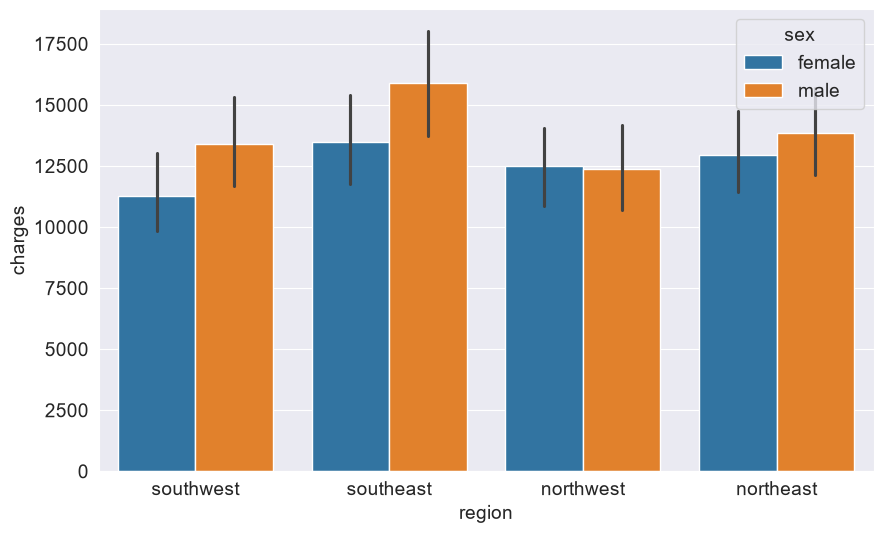

In [22]:
fig = sns.barplot(medical_df, x='region', y='charges', hue='sex')


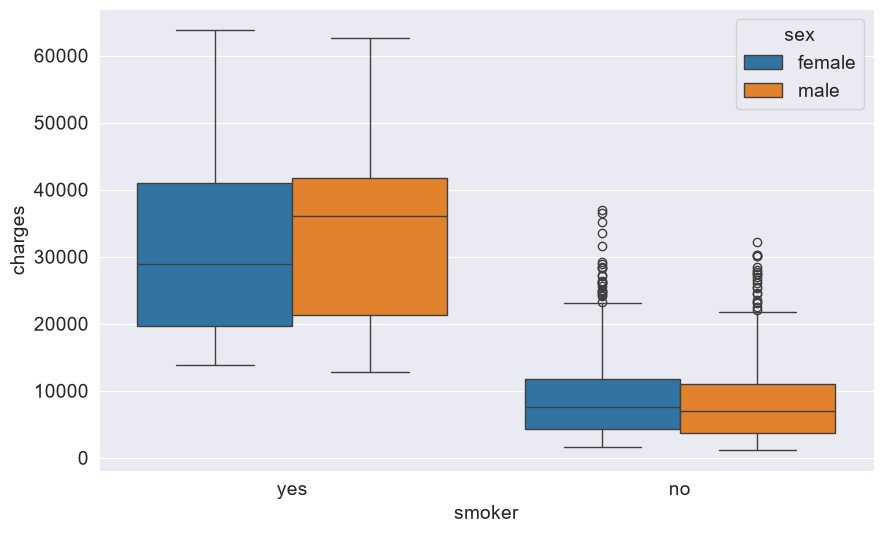

In [23]:
fig = sns.boxplot(medical_df, x='smoker', y='charges', hue='sex')

In [24]:
medical_df.charges.corr(medical_df.age)

np.float64(0.2990081933306478)

In [25]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362887)

In [26]:
medical_df.charges.corr(medical_df.children)

np.float64(0.06799822684790487)

In [27]:
smoker_numeric = medical_df.smoker.map({'yes': 1, 'no': 0})
medical_df.charges.corr(smoker_numeric)

np.float64(0.7872514304984778)

In [28]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


Text(0.5, 1.0, 'Correlation Heatmap of Medical Dataset')

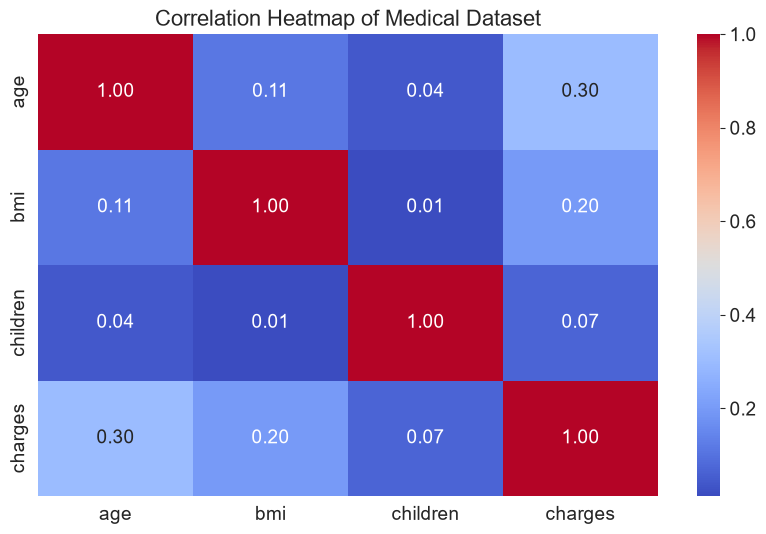

In [29]:
sns.heatmap(medical_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Medical Dataset', fontsize=16)

In [30]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

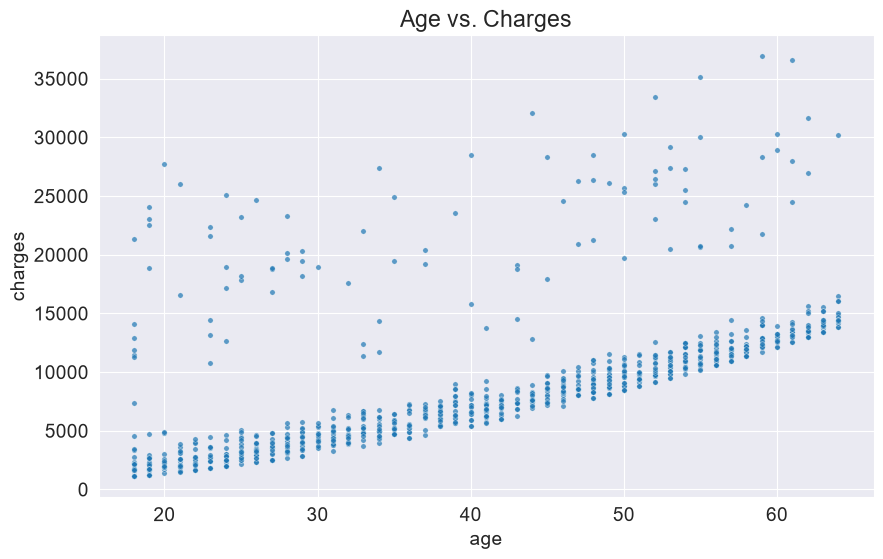

In [31]:
plt.title('Age vs. Charges')
sns.scatterplot(data=non_smoker_df, x='age', y='charges', alpha=0.7, s=15);

In [32]:
def estimate_charges(age,w,b):
    return w * age + b

In [33]:
w = 50
b = 100

In [34]:
estimate_charges(30, w, b)

1600

In [35]:
age = non_smoker_df.age
age

1       18
2       28
3       33
4       32
5       31
        ..
1332    52
1333    50
1334    18
1335    18
1336    21
Name: age, Length: 1064, dtype: int64

In [36]:
estimated_charges = estimate_charges(age, w, b)
estimated_charges

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [37]:
non_smoker_df.charges

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

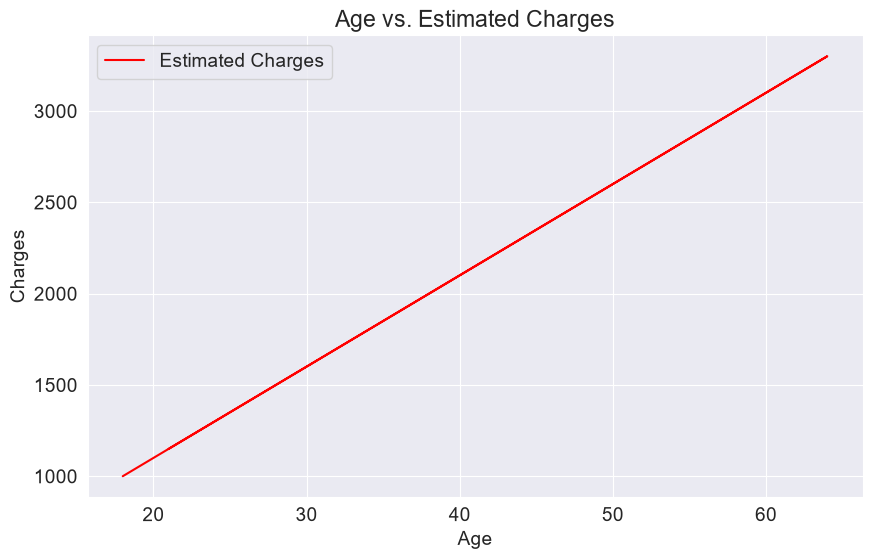

In [38]:
plt.plot(age, estimated_charges, color='red', label='Estimated Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs. Estimated Charges')
plt.legend()
plt.show()

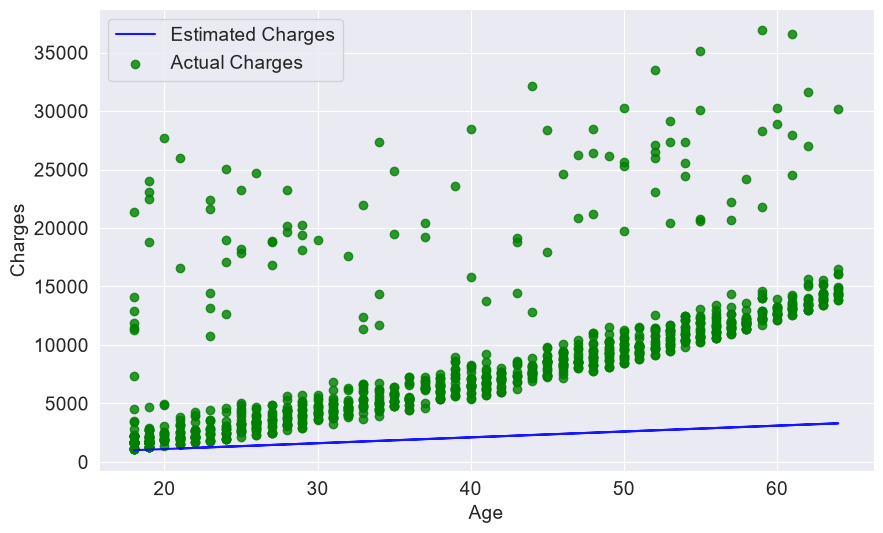

In [39]:
target = non_smoker_df.charges
plt.plot(age, estimated_charges, color='blue', label='Estimated Charges',alpha = 0.9);
plt.scatter(age, target, color='green', label='Actual Charges', alpha=0.8);
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(['Estimated Charges','Actual Charges'])

In [40]:
def try_parameters(w, b):
    estimated_charges = estimate_charges(age, w, b)
    plt.plot(age, estimated_charges, color='blue', label='Estimated Charges', alpha=0.9)
    plt.scatter(age, target, color='green', label='Actual Charges', alpha=0.8)
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Estimated Charges', 'Actual Charges'])
    plt.title(f'Estimated vs Actual Charges (w={w}, b={b})')
    plt.show()

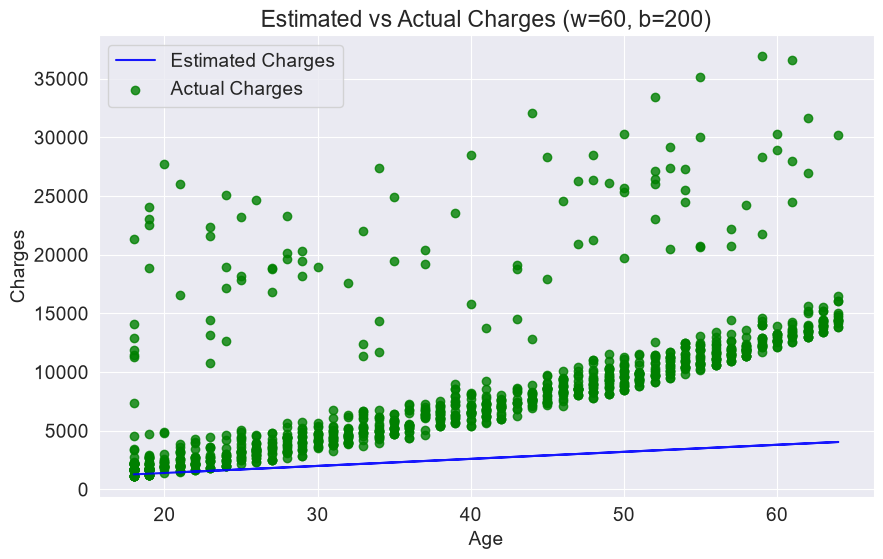

In [41]:
try_parameters(60, 200)

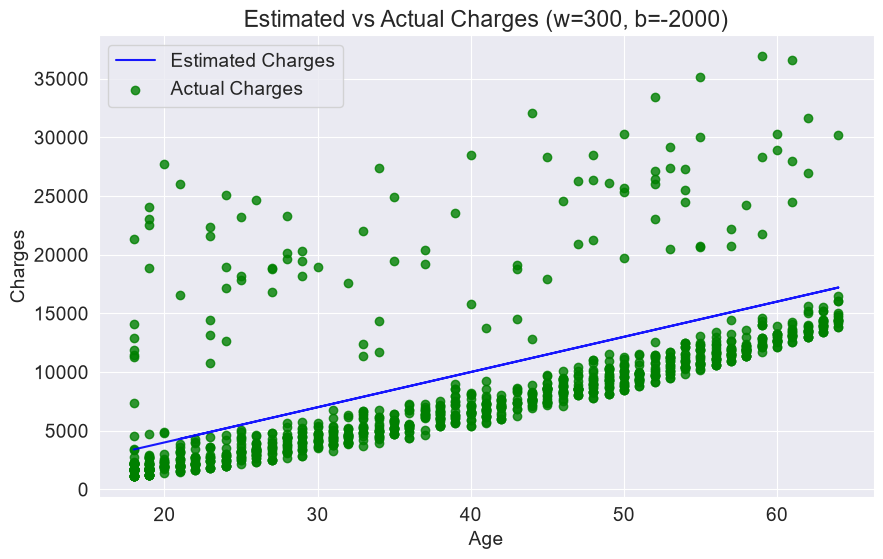

In [42]:
try_parameters(300, -2000)

In [43]:
#automating linear regression 
import numpy as np
def rmse(targets, predictions):
    return np.sqrt(np.mean((targets - predictions) ** 2))

In [44]:
targets = non_smoker_df.charges
predictions = estimate_charges(age, 280, -3000)
rmse(targets, predictions)

np.float64(4683.622287033994)

In [45]:
def try_parameters(w, b):
    estimated_charges = estimate_charges(age, w, b)
    plt.plot(age, estimated_charges, color='blue', label='Estimated Charges', alpha=0.9)
    plt.scatter(age, target, color='green', label='Actual Charges', alpha=0.8)
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Estimated Charges', 'Actual Charges'])
    plt.title(f'Estimated vs Actual Charges (w={w}, b={b})')
    plt.show()
    
    rmse_value = rmse(targets, estimated_charges)
    print(f'RMSE for w={w}, b={b}: {rmse_value:.2f}')

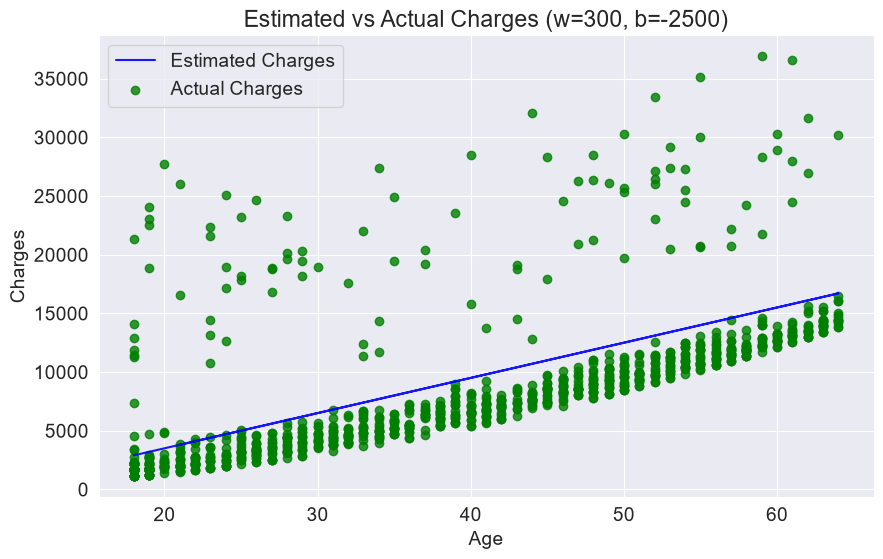

RMSE for w=300, b=-2500: 4767.42


In [46]:
try_parameters(300, -2500)

In [47]:
#linear regression using sklearn
from sklearn.linear_model import LinearRegression
model = LinearRegression()
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [48]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
print('inputs.shape :', inputs.shape)
print('targets.shape :', targets.shape)

inputs.shape : (1064, 1)
targets.shape : (1064,)


In [49]:
model.fit(inputs, targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[267.25]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['age']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2091
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [50]:
model.predict(np.array([[23], 
                        [37], 
                        [61]]))

c:\Users\NARENDRA G S\OneDrive\Desktop\Projects\ML - learn\medical expense\.venv-1\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [51]:
predicted_charges = model.predict(inputs)
predicted_charges

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [52]:
rmse(targets, predicted_charges)

np.float64(4662.505766636395)

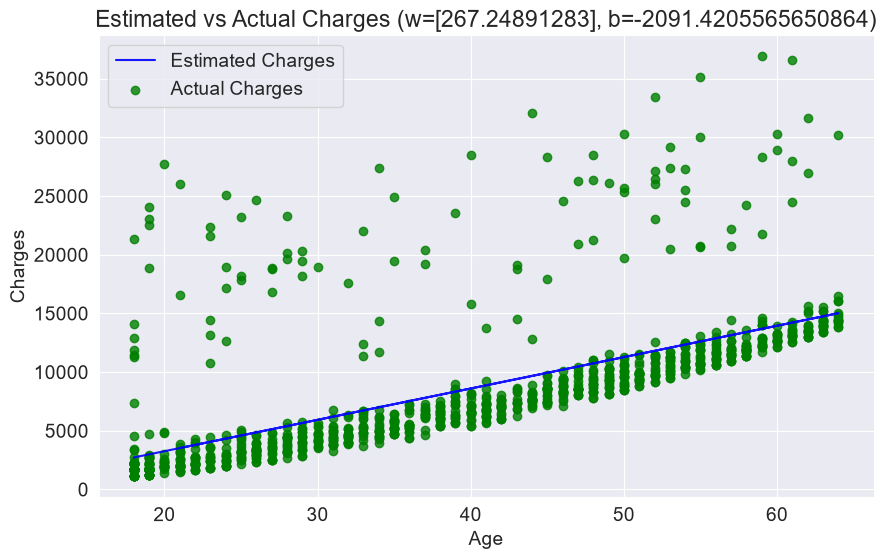

RMSE for w=[267.24891283], b=-2091.4205565650864: 4662.51


In [53]:
try_parameters(model.coef_, model.intercept_)

In [54]:
from sklearn.linear_model import SGDRegressor
gradient_model = SGDRegressor()
help(gradient_model.fit)

Help on method fit in module sklearn.linear_model._stochastic_gradient:

fit(X, y, coef_init=None, intercept_init=None, sample_weight=None) method of sklearn.linear_model._stochastic_gradient.SGDRegressor instance
    Fit linear model with Stochastic Gradient Descent.

    Parameters
    ----------
    X : {array-like, sparse matrix}, shape (n_samples, n_features)
        Training data.

    y : ndarray of shape (n_samples,)
        Target values.

    coef_init : ndarray of shape (n_features,), default=None
        The initial coefficients to warm-start the optimization.

    intercept_init : ndarray of shape (1,), default=None
        The initial intercept to warm-start the optimization.

    sample_weight : array-like, shape (n_samples,), default=None
        Weights applied to individual samples (1. for unweighted).

    Returns
    -------
    self : object
        Fitted `SGDRegressor` estimator.



In [55]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
print('inputs.shape :', inputs.shape)
print('targets.shape :', targets.shape)

inputs.shape : (1064, 1)
targets.shape : (1064,)


In [56]:
gradient_model.fit(inputs, targets)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None


In [57]:
gradient_model.coef_,gradient_model.intercept_

(array([237.70966338]), array([2361.0237497]))

In [58]:
gradient_predicted_charges = gradient_model.predict(inputs)

In [59]:
rmse(targets, gradient_predicted_charges)

np.float64(5720.977995000451)

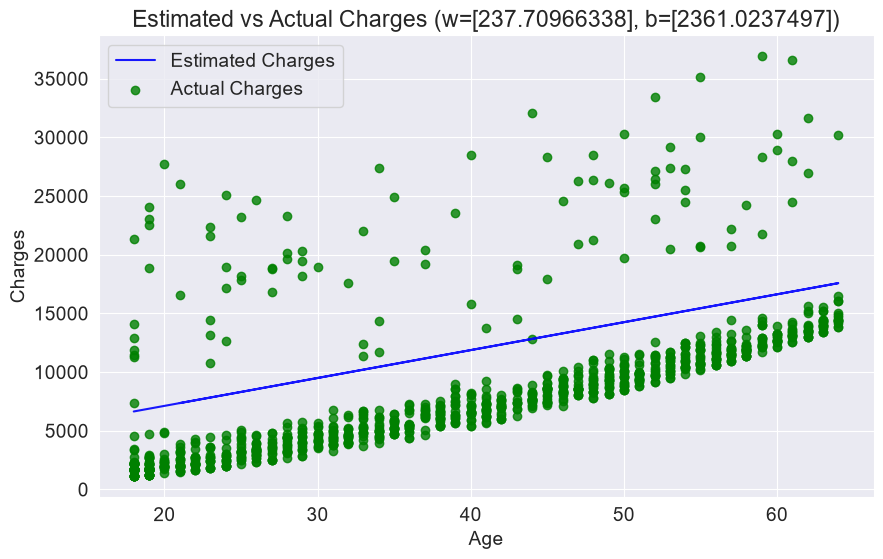

RMSE for w=[237.70966338], b=[2361.0237497]: 5720.98


In [60]:
try_parameters(gradient_model.coef_, gradient_model.intercept_)

In [63]:
input, target = non_smoker_df[['age']], non_smoker_df.charges

model = LinearRegression().fit(input, target)

predictions = model.predict(input)
loss = rmse(target,predictions)
print('Loss: ', loss)

Loss:  4662.505766636395


In [65]:
input, target =non_smoker_df[['age','bmi']],non_smoker_df['charges']

model = LinearRegression().fit(input,target)

predicted_charges = model.predict(input)

loss = rmse(target,predicted_charges)
print("Loss: ",loss)

Loss:  4662.3128354612945


In [66]:
input, target =non_smoker_df[['age','bmi','children']],non_smoker_df['charges']

model = LinearRegression().fit(input,target)

predicted_charges = model.predict(input)

loss = rmse(target,predicted_charges)
print("Loss: ",loss)

Loss:  4608.470405038246
